In [1]:
! git checkout module-10

Already on 'module-10'


In [2]:
# Import Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

from zipfile import ZipFile
from urllib.request import urlretrieve

%matplotlib inline

In [3]:
# def download_and_unzip(url, save_path):
#     print(f"Downloading and extracting assests....", end="")

#     # Downloading zip file using urllib package.
#     urlretrieve(url, save_path)

#     try:
#         # Extracting zip file using the zipfile package.
#         with ZipFile(save_path) as z:
#             # Extract ZIP file contents in the same directory.
#             z.extractall(os.path.split(save_path)[0])

#         print("Done")

#     except Exception as e:
#         print("\nInvalid file.", e)

In [4]:
# URL = r"https://www.dropbox.com/s/qa1hsyxt66pvj02/opencv_bootcamp_assets_NB10.zip?dl=1"

# asset_zip_path = os.path.join(os.getcwd(), "opencv_bootcamp_assets_NB10.zip")

# # Download if assest ZIP does not exists.
# if not os.path.exists(asset_zip_path):
#     download_and_unzip(URL, asset_zip_path)

In [5]:
def readImagesAndTimes():
    times = np.array([1/30.0, 0.25, 2.5, 15.0], dtype = np.float32)
    fileNames = ["img_0.033.jpg", "img_0.25.jpg", "img_2.5.jpg", "img_15.jpg"]

    images = []
    for fileName in fileNames:
        img = cv2.imread(fileName, cv2.IMREAD_COLOR)
        images.append(img)
    return images , times

# def readImagesAndTimes():
#     # List of file names
#     filenames = ["img_0.033.jpg", "img_0.25.jpg", "img_2.5.jpg", "img_15.jpg"]

#     # List of exposure times
#     times = np.array([1 / 30.0, 0.25, 2.5, 15.0], dtype=np.float32)

#     # Read images
#     images = []
#     for filename in filenames:
#         im = cv2.imread(filename)
#         images.append(im)

#     return images, times                 

In [6]:
images , times = readImagesAndTimes()

# align images

alignMTB = cv2.createAlignMTB()
alignMTB.process(images, images)


# Estimating camera response function

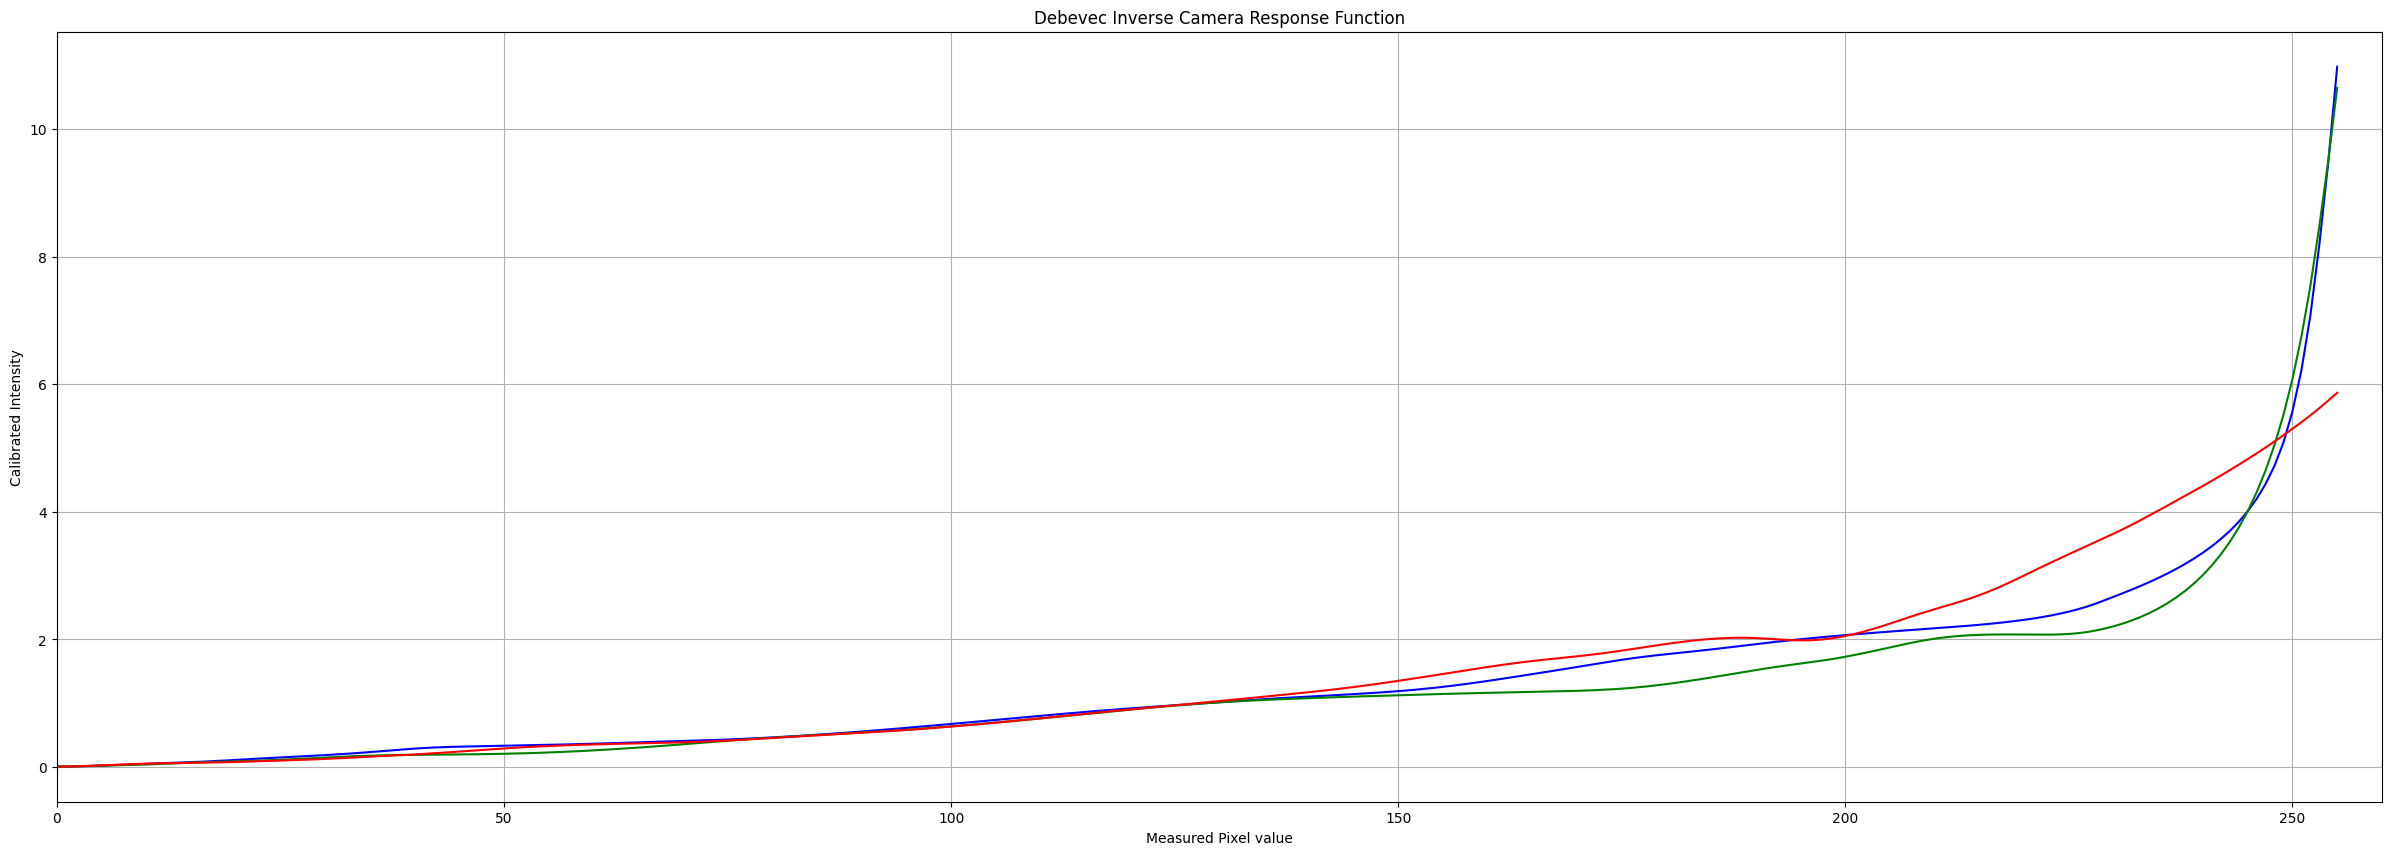

In [7]:
calibrateDebevec = cv2.createCalibrateDebevec()
responseDebevec = calibrateDebevec.process(images, times)

# plotting CRF
x = np.arange(256, dtype = np.uint8)
y = np.squeeze(responseDebevec)

plt.figure(figsize = [30,10])
plt.title("Debevec Inverse Camera Response Function")
plt.xlabel("Measured Pixel value")
plt.ylabel("Calibrated Intensity")
plt.xlim([0,260])
plt.grid()
plt.plot(x,y[:, 0], "b", x, y[:, 1], "g", x, y[:,2], "r")

# merge exposure into a HDR img


In [8]:
mergeDebevec = cv2.createMergeDebevec()
hdrDebevec = mergeDebevec.process(images, times, responseDebevec)

# Tonemapping

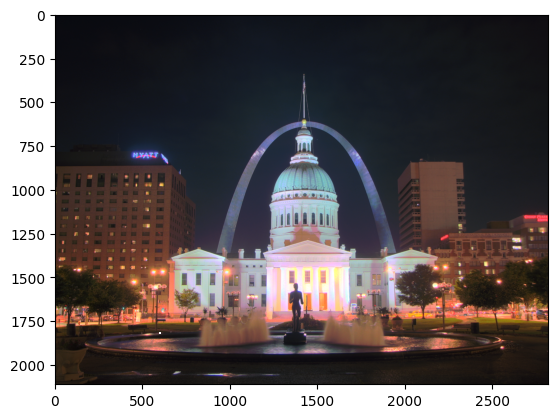

In [9]:
#Using Drago's method
tonemapDrago = cv2.createTonemapDrago(1.0, 0.7)
ldrDrago = tonemapDrago.process(hdrDebevec)
ldrDrago = 3 * ldrDrago
cv2.imwrite("ldr-drago.jpg", 255*ldrDrago)
plt.imshow(np.clip(ldrDrago, 0, 1)[:,:,::-1])

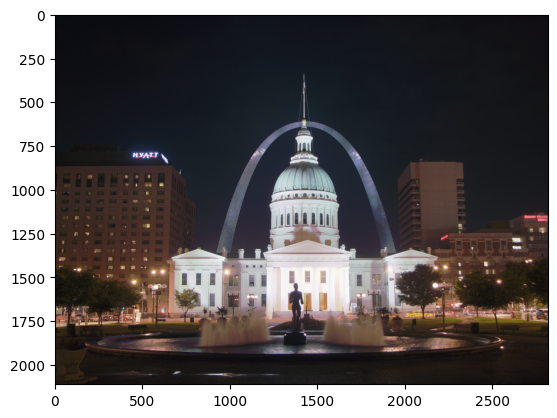

In [24]:
# Tonemap Reinhard's method
tonemapReinhard = cv2.createTonemapReinhard(1.5,0,0,0)
ldrReinhard = tonemapReinhard.process(hdrDebevec)
cv2.imwrite("ldr-reinhard.jpg", np.uint8(255*(np.clip(ldrReinhard, 0, 1))))
plt.imshow(np.clip(ldrReinhard, 0, 1)[:,:,::-1])

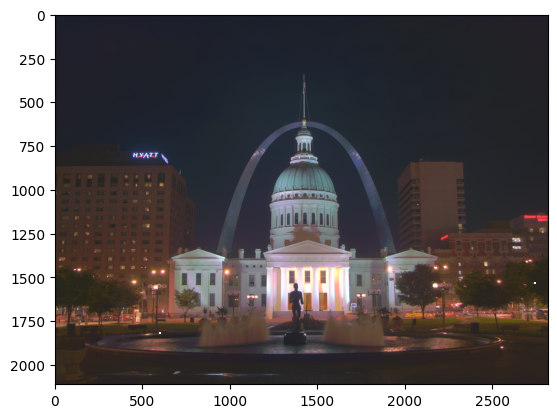

In [22]:
# Tonemap using Mantiuk's method
tonemapMantiuk = cv2.createTonemapMantiuk(2.2, 0.85, 1.2)
ldrMantiuk = tonemapMantiuk.process(hdrDebevec)
ldrMantiuk = ldrMantiuk*3
cv2.imwrite("ldr-mantiuk.jpg",255*ldrMantiuk)

plt.imshow(np.clip(ldrMantiuk, 0, 1)[:,:,::-1])

In [25]:
! git status

On branch module-10
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	img_0.033.jpg
	img_0.25.jpg
	img_15.jpg
	img_2.5.jpg
	ldr-drago.jpg
	ldr-mantiuk.jpg
	ldr-reinhard.jpg
	module-10.ipynb
	opencv_bootcamp_assets_NB1.zip
	opencv_bootcamp_assets_NB10.zip
	opencv_bootcamp_assets_NB2.zip
	opencv_bootcamp_assets_NB3.zip
	opencv_bootcamp_assets_NB4.zip
	opencv_bootcamp_assets_NB6.zip
	opencv_bootcamp_assets_NB8.zip
	opencv_bootcamp_assets_NB9.zip
	race_car.mp4
	race_car_out.avi
	race_car_out.mp4

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
! git add img_0.033.jpg 